**🦜🔗LangChain is like a giant toolbox + duct tape kit. It gives you abstractions (chains, agents, memory, tools, retrievers, etc.) that you can snap together to make an LLM-powered app. It’s very flexible but can get messy—people sometimes say it feels like a jungle gym of components.**

**🔗📊LangGraph is more like a circuit board where you draw out the flow of your app. Instead of chaining functions in a linear sequence, it leans on graph-based workflows. You define nodes (like “call LLM,” “search database,” “filter output”) and edges (the paths between them). It’s built on top of LangChain but brings structure for handling loops, branching, and state management in a cleaner way.**

**LangChain 🛠️ = general-purpose framework to build LLM apps with chains, agents, tools.**

**LangGraph 🔗📊 = built on LangChain, uses graph-based workflows.**

**LangChain ⚡ = super flexible but can get messy for complex apps.**

**LangGraph 🎯 = structured with nodes, edges, loops, branching for cleaner flow.**

### what is AI agent ?
**AI agents are basically LLMs with a brain + arms.**

**The brain 🧠 is the large language model (like GPT), which can understand and generate text.**

**The arms 🤖 are the tools or actions it can take — like searching Google, calling an API, querying a database, or running code.**


In [1]:
def function1(input1):
    return input1   +  " From the first Function"



In [2]:
def function2(input2):
    return input2  +  " charan From the second Function"

In [3]:
def function3(input3):
    pass

In [4]:
function1("Hello AI Learners! ")

'Hello AI Learners!  From the first Function'

In [5]:
function2("Hello Charan! welcome to Langgraph ")

'Hello Charan! welcome to Langgraph  charan From the second Function'

In [6]:
from langgraph.graph import StateGraph, START, END


In [7]:
workflow1 = StateGraph(dict)

In [8]:
workflow1.add_node("fun1",function1)

In [9]:
workflow1.add_node("fun2",function2)

In [10]:
workflow1.add_edge("fun1","fun2")

In [11]:
workflow1.set_entry_point("fun1")

In [12]:
workflow1.set_finish_point("fun2")

In [13]:

app=workflow1.compile()

In [14]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'fun1': Node(id='fun1', name='fun1', data=fun1(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'fun2': Node(id='fun2', name='fun2', data=fun2(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='fun1', data=None, conditional=False), Edge(source='fun1', target='fun2', data=None, conditional=False), Edge(source='fun2', target='__end__', data=None, conditional=False)])

### Displaying Workflow

In [15]:

from IPython.display import Image, display

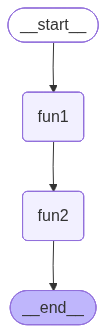

In [16]:
display(Image(app.get_graph().draw_mermaid_png()))

In [17]:
app.invoke("hi iam sai ")

'hi iam sai  From the first Function charan From the second Function'

In [18]:
for output in app.stream("hi this is saicharan"):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")

here is output from fun1
_______
hi this is saicharan From the first Function


here is output from fun2
_______
hi this is saicharan From the first Function charan From the second Function




### LLM CALL

In [54]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')
os.environ['GOOGLE_API_KEY'] = os.getenv("GOOGLE_API_KEY")

In [57]:
from langchain_google_genai import ChatGoogleGenerativeAI
model=ChatGoogleGenerativeAI(model='gemini-2.5-pro')

E0000 00:00:1759504767.719032 2805542 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [58]:

model.invoke("hi").content

'Hello! How can I help you today?'

In [59]:
def llm(input):
    from langchain_google_genai import ChatGoogleGenerativeAI
    model=ChatGoogleGenerativeAI(model='gemini-1.5-flash')
    output=model.invoke(input)
    return output.content

In [61]:
def token_counter(input):
    token=input.split()
    token_number=len(token)
    return f"total token number in the generated answer is {token_number}"

In [62]:
from langgraph.graph import StateGraph




In [63]:
workflow2 = StateGraph(dict)

In [64]:
workflow2.add_node("My_LLM",llm)

In [65]:
workflow2.add_node("LLM_Output_Token_Counter",token_counter)

In [66]:

workflow2.add_edge("My_LLM","LLM_Output_Token_Counter")

In [67]:
workflow2.set_entry_point("My_LLM")

In [68]:

workflow2.set_finish_point("LLM_Output_Token_Counter")

In [69]:

app=workflow2.compile()

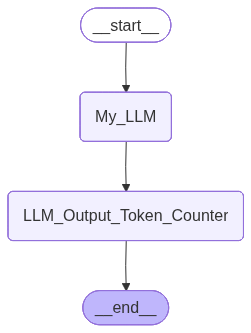

In [70]:

display(Image(app.get_graph().draw_mermaid_png()))